# 第5章 多元线性回归

## 5.1 二元线性回归

In [1]:
* 柯布和道格拉斯使用美国1899-1922年制造业产出(y)、资本(k)与劳动力(l)的数据
use data/cobb_douglas.dta, clear
list

(Cobb & Douglas 1928 paper)

     +---------------------------------------------------------+
     | year     k     l     y        lnk        lnl        lny |
     |---------------------------------------------------------|
  1. | 1899   100   100   100    4.60517    4.60517    4.60517 |
  2. | 1900   107   105   101   4.672829    4.65396    4.61512 |
  3. | 1901   114   110   112   4.736198    4.70048   4.718499 |
  4. | 1902   122   118   122   4.804021   4.770685   4.804021 |
  5. | 1903   131   123   124   4.875197   4.812184   4.820282 |
     |---------------------------------------------------------|
  6. | 1904   138   116   122   4.927254    4.75359   4.804021 |
  7. | 1905   149   125   143   5.003946   4.828314   4.962845 |
  8. | 1906   163   133   152    5.09375   4.890349    5.02388 |
  9. | 1907   176   138   151   5.170484   4.927254    5.01728 |
 10. | 1908   185   121   126   5.220356   4.795791   4.836282 |
     |-------------------------------------------------------

变量k, l与y均将1899年的取值标准化为100(以1899年为指数的基期),而lnk, lnl与lny分别为其对数值。

In [2]:
* 进行二元线性回归估计
reg lny lnk lnl


      Source |       SS           df       MS      Number of obs   =        24
-------------+----------------------------------   F(2, 21)        =    236.12
       Model |  1.59622155         2  .798110773   Prob > F        =    0.0000
    Residual |  .070981736        21  .003380083   R-squared       =    0.9574
-------------+----------------------------------   Adj R-squared   =    0.9534
       Total |  1.66720328        23  .072487099   Root MSE        =    .05814

------------------------------------------------------------------------------
         lny | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lnk |   .2330537   .0635298     3.67   0.001     .1009363    .3651711
         lnl |    .807278   .1450762     5.56   0.000     .5055755    1.108981
       _cons |  -.1773099   .4342933    -0.41   0.687    -1.080472    .7258525
--------------------------------------------------

lnk(资本对数)与lnl(劳动力对数)的系数分别为0.233与0.807，且拟合优度$R^2$高达0.957。这种形式的生产函数后来被称为“柯布-道格拉斯生产函数”。

In [3]:
* 用命令predict来计算拟合值与残差。此命令将ln y的拟合值记为“lny1”
predict lny1
* 如果要计算残差，并记为e，可输入命令
* 选择项“residuel”表示计算残差(如果省略此选择项，则默认为计算拟合值)
predict e,residual
* 下面，将lny及其拟合值、残差同时列表。
list lny lny1 e

(option xb assumed; fitted values)

     +---------------------------------+
     |      lny       lny1           e |
     |---------------------------------|
  1. |  4.60517   4.613595   -.0084246 |
  2. |  4.61512    4.66875   -.0536295 |
  3. | 4.718499   4.721073   -.0025745 |
  4. | 4.804021   4.793554     .010467 |
  5. | 4.820282   4.843644   -.0233621 |
     |---------------------------------|
  6. | 4.804021   4.808474   -.0044528 |
  7. | 4.962845    4.88667    .0761749 |
  8. |  5.02388   4.957679    .0662019 |
  9. |  5.01728   5.005354    .0119254 |
 10. | 4.836282    4.91085    -.074568 |
     |---------------------------------|
 11. | 5.043425    5.04442   -.0009945 |
 12. | 5.068904   5.078644   -.0097398 |
 13. | 5.030438   5.093026   -.0625884 |
 14. |  5.17615   5.141634    .0345157 |
 15. | 5.214936   5.162277    .0526584 |
     |---------------------------------|
 16. | 5.129899   5.143401   -.0135028 |
 17. | 5.241747   5.190166    .0515813 |
 18. | 5.416101   5.3

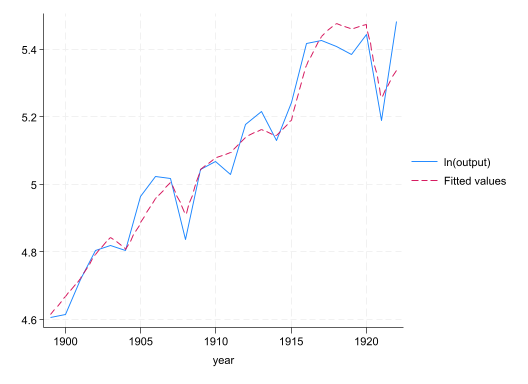

In [4]:
* 可将产出对数及其拟合值画在一起
line lny lny1 year,lp(solid dash)

## 5.12 多元线性回归的 Stata 命令及实例

In [5]:
* 该数据集包括758名美国年轻男子的数据。
* 被解释变量为lnw(工资对数),主要解释变量包括s(教育年限)、expr(工龄)、tenure(在现单位工作年限)、smsa(是否住在大城市)以及rns(是否住在美国南方)。
use data/grilic.dta,clear
reg lnw s expr tenure smsa rns


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(5, 752)       =     81.75
       Model |  49.0478814         5  9.80957628   Prob > F        =    0.0000
    Residual |  90.2382684       752  .119997697   R-squared       =    0.3521
-------------+----------------------------------   Adj R-squared   =    0.3478
       Total |   139.28615       757  .183997556   Root MSE        =    .34641

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |    .102643   .0058488    17.55   0.000     .0911611     .114125
        expr |   .0381189   .0063268     6.02   0.000     .0256986    .0505392
      tenure |   .0356146   .0077424     4.60   0.000     .0204153    .0508138
        smsa |   .1396666   .0280821     4.97   0.

* 表上方的回归结果显示，残差平方和$\sum_{i=1}^n e$=90.24,方程的标准误差(Root MSE)为s=0.34641。
* 检验整个方程显著性的F统计量为81.75,其对应的p值(Prob>F)为0.0000,表明这个回归方程整体是高度显著的。
* 所有解释变量(包括常数项)的回归系数的p值(P>|t|)都小于0.01,故均在1%平上显著,而且符号与理论预期一致。
* 教育年限(s)的系数估计值为0.103,即教育投资回报率为10.3%。工龄(expr)与在现单位工作年限(tenure)的回报率分别为3.8%与3.6%(可视为在职培训的回报率),小于正规教育的回报率。
* 住在大城市的回报率高达14.0%，甚至高于一年教育的回报率，说明了环境的重要性。
* 变量rns的系数为-0.084，表明在给定其他变量的情况下，南方居民的工资比北方居民低8.4%。
* 常数项的估计值为4.104,这意味着未受任何教育(s=0)、也无工作经验(expr=tenure=0)、不住在大城市(smsa=0)，且身在北方(ms=0)的年轻男子预期工资对数为4.104。

In [6]:
* 如果要显示回归系数的协方差矩阵，可输入命令
* “vce”表示“variance covariance matrix estimated”
vce


Covariance matrix of coefficients of regress model

        e(V) |          s        expr      tenure        smsa         rns 
-------------+------------------------------------------------------------
           s |  .00003421                                                 
        expr |  8.660e-06   .00004003                                     
      tenure | -3.997e-08  -.00001107   .00005994                         
        smsa |  -.0000144   3.261e-06  -7.819e-06   .00078861             
         rns |  8.524e-06   7.334e-07   7.259e-06   .00012486   .00082928 
       _cons | -.00046567  -.00016778  -.00008646  -.00038746  -.00043997 

        e(V) |      _cons 
-------------+-----------
       _cons |   .0072415 


上表中的主对角线元素为各回归系数的方差，而非主对角线元素则为相应的协方差。

In [7]:
* 尽管在上述回归中常数项很显著,为演示目的，下面加上选择项“noconstant”,进行无常数项回归：
reg lnw s expr tenure smsa rns,noc


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(5, 753)       =   9902.73
       Model |  24282.9531         5  4856.59061   Prob > F        =    0.0000
    Residual |  369.293555       753  .490429688   R-squared       =    0.9850
-------------+----------------------------------   Adj R-squared   =    0.9849
       Total |  24652.2466       758  32.5227528   Root MSE        =    .70031

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |   .3665333   .0041742    87.81   0.000     .3583389    .3747277
        expr |   .1331991   .0121535    10.96   0.000     .1093403    .1570578
      tenure |   .0846129   .0155168     5.45   0.000     .0541515    .1150743
        smsa |   .3592339   .0560206     6.41   0.

从上表可知，根据无常数项回归的估计，教育投资回报率每年高达36.7%，这显然不合理。由于常数项很显著，故忽略常数项将导致估计偏差，得不到一致估计。

In [8]:
* 如果只对南方居民的子样本进行回归，可使用虚拟变量rns
reg lnw s expr tenure smsa if rns


      Source |       SS           df       MS      Number of obs   =       204
-------------+----------------------------------   F(4, 199)       =     36.07
       Model |   17.603542         4  4.40088551   Prob > F        =    0.0000
    Residual |  24.2783596       199  .122001807   R-squared       =    0.4203
-------------+----------------------------------   Adj R-squared   =    0.4087
       Total |  41.8819016       203  .206314786   Root MSE        =    .34929

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |   .1198242   .0113156    10.59   0.000     .0975103    .1421381
        expr |   .0451903   .0122572     3.69   0.000     .0210197     .069361
      tenure |   .0092643   .0156779     0.59   0.555    -.0216518    .0401804
        smsa |   .1746563   .0506762     3.45   0.

In [9]:
* 如果只对北方居民的子样本进行回归，可使用命令
* reg lnw s expr tenure smsa if ~rns
* 也可使用“!”，效果相同。
reg lnw s expr tenure smsa if !rns


      Source |       SS           df       MS      Number of obs   =       554
-------------+----------------------------------   F(4, 549)       =     62.45
       Model |   29.486457         4  7.37161426   Prob > F        =    0.0000
    Residual |  64.8019636       549  .118036364   R-squared       =    0.3127
-------------+----------------------------------   Adj R-squared   =    0.3077
       Total |  94.2884207       553  .170503473   Root MSE        =    .34356

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |   .0944787   .0068365    13.82   0.000     .0810498    .1079076
        expr |   .0358675   .0073558     4.88   0.000     .0214184    .0503165
      tenure |   .0455117   .0088792     5.13   0.000     .0280703    .0629531
        smsa |   .1199364   .0337443     3.55   0.

In [10]:
* 如果只对中学以上(s≥12)的子样本进行回归，可输人命令
reg lnw s expr tenure smsa rns if s>=12


      Source |       SS           df       MS      Number of obs   =       679
-------------+----------------------------------   F(5, 673)       =     69.81
       Model |  41.8750434         5  8.37500867   Prob > F        =    0.0000
    Residual |  80.7410668       673  .119971867   R-squared       =    0.3415
-------------+----------------------------------   Adj R-squared   =    0.3366
       Total |   122.61611       678   .18084972   Root MSE        =    .34637

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |   .1077261   .0066792    16.13   0.000     .0946115    .1208408
        expr |   .0344524   .0071189     4.84   0.000     .0204745    .0484304
      tenure |   .0363033   .0082594     4.40   0.000     .0200859    .0525206
        smsa |   .1583146   .0298248     5.31   0.

In [11]:
* 如果只对中学以上(s≥12)且在南方居住的子样本进行回归，可输入命令
reg lnw s expr tenure smsa if s>=12 & rns


      Source |       SS           df       MS      Number of obs   =       174
-------------+----------------------------------   F(4, 169)       =     32.17
       Model |   15.404067         4  3.85101675   Prob > F        =    0.0000
    Residual |  20.2300414       169  .119704387   R-squared       =    0.4323
-------------+----------------------------------   Adj R-squared   =    0.4188
       Total |  35.6341084       173  .205977505   Root MSE        =    .34598

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |   .1269124   .0131847     9.63   0.000     .1008845    .1529404
        expr |   .0226531   .0156062     1.45   0.148    -.0081551    .0534613
      tenure |   .0146869   .0182079     0.81   0.421    -.0212573    .0506312
        smsa |   .2136309   .0548788     3.89   0.

In [12]:
* 前缀“quietly”表示不汇报回归结果
quietly reg lnw s expr tenure smsa rns
* 如果要计算被解释变量的拟合值,并将其记为“lnw1”,可使用命令
predict lnw1
* 如果要计算残差，并将其记为“e”,可输人命令
predict e,residual

(option xb assumed; fitted values)


考虑检验教育投资回报率是否为10%，即检验原假设$H_0:\beta_2=0.1$，可使用如下命令

In [13]:
test s=0.1


 ( 1)  s = .1

       F(  1,   752) =    0.20
            Prob > F =    0.6515


由于t分布的平方为F分布，故Stata统一汇报F统计量及其p值。上表显示，p值=0.6515,故无法拒绝原假设。

对于单个系数的检验，手工计算t统计量也十分方便：
$$
t=\frac{估计量-假想值}{估计量的标准误}=\frac{0.102643-0.1}{0.0058488}=0.45188757=t(n-K)=t(752)
$$

In [14]:
* 由于默认为双边检验，故可计算此t统计量对应的p值如下
* “ttail(752,0.45188757)”表示自由度为752的t分布比0.45188757更大的右侧尾部概率，正好是反向的累积分布函数
dis ttail(752,0.45188757)*2

.65148029


如果要进行单边检验，比如原假设仍为$H_0:\beta_2=0.1$，而替代假设为$H_1:\beta_2>0.1$，则拒绝域在t分布的右侧尾部。

In [15]:
* 相应的t统计量仍为0.45188757,但在计算p值时，只需计算大于此t统计量的右侧尾部概率即可
dis ttail(752,0.45188757)

.32574014


由于p值仍高达0.3257，故依然可以接受原假设。

下面考虑检验 expr 与 tenure的系数是否相等，即检验$H_0:\beta_3=\beta_4$，可输入命令：

In [16]:
test expr=tenure


 ( 1)  expr - tenure = 0

       F(  1,   752) =    0.05
            Prob > F =    0.8208


由于p值=0.8208，可以轻松地接受原假设。

考虑检验工龄回报率与在现单位工作年限回报率之和是否等于教育投资回报率，即$H_0:\beta_3+\beta_4=\beta_2$，可使用命令：

In [17]:
test expr+tenure=s


 ( 1)  - s + expr + tenure = 0

       F(  1,   752) =    8.82
            Prob > F =    0.0031


由于p值=0.0031，故可在1%显著性水平上拒绝原假设，即认为$\beta_3+\beta_4\neq\beta_2$。